In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

In [2]:
df=pd.read_csv("KPT_Dataset.csv")
print("Shape:",df.shape)
print('\n df SUMMARY:')
print(df.info())
print(df.head(2))

Shape: (30000, 20)

 df SUMMARY:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   order_id                  30000 non-null  int64  
 1   restaurant_id             30000 non-null  int64  
 2   city                      30000 non-null  object 
 3   order_confirm_time        30000 non-null  object 
 4   actual_ready_time         30000 non-null  object 
 5   merchant_marked_FOR_time  30000 non-null  object 
 6   rider_arrival_time        30000 non-null  object 
 7   rider_pickup_time         30000 non-null  object 
 8   actual_prep_time_min      30000 non-null  float64
 9   observed_prep_time_min    30000 non-null  float64
 10  rider_wait_time_min       30000 non-null  float64
 11  is_peak_hour              30000 non-null  int64  
 12  order_hour                30000 non-null  int64  
 13  is_peak_hour_enhanced     30

In [3]:
print(df.isnull().sum())


order_id                    0
restaurant_id               0
city                        0
order_confirm_time          0
actual_ready_time           0
merchant_marked_FOR_time    0
rider_arrival_time          0
rider_pickup_time           0
actual_prep_time_min        0
observed_prep_time_min      0
rider_wait_time_min         0
is_peak_hour                0
order_hour                  0
is_peak_hour_enhanced       0
day_of_week                 0
historical_avg_prep         0
prep_time_deviation         0
high_wait_flag              0
delay_flag                  0
rush_intensity_score        0
dtype: int64


In [4]:
print("Basic Statistics:\n")
print(df[[
    "actual_prep_time_min",
    "observed_prep_time_min",
    "rider_wait_time_min"
]].describe())

Basic Statistics:

       actual_prep_time_min  observed_prep_time_min  rider_wait_time_min
count          30000.000000            30000.000000         30000.000000
mean              19.992185               23.034189             6.300584
std                6.244943                6.585402             6.611318
min                5.000000                5.000000             0.000000
25%               15.640000               18.430000             0.000000
50%               19.410000               22.460000             4.680000
75%               23.750000               27.070000            10.300000
max               55.970000               61.040000            44.700000


----- Outlier Analysis (IQR Method) -----

Column: actual_prep_time_min
Lower Bound: 3.48
Upper Bound: 35.91
Total Outliers: 436
Outlier %: 1.45%

Column: observed_prep_time_min
Lower Bound: 5.47
Upper Bound: 40.03
Total Outliers: 384
Outlier %: 1.28%

Column: rider_wait_time_min
Lower Bound: -15.45
Upper Bound: 25.75
Total Outliers: 325
Outlier %: 1.08%


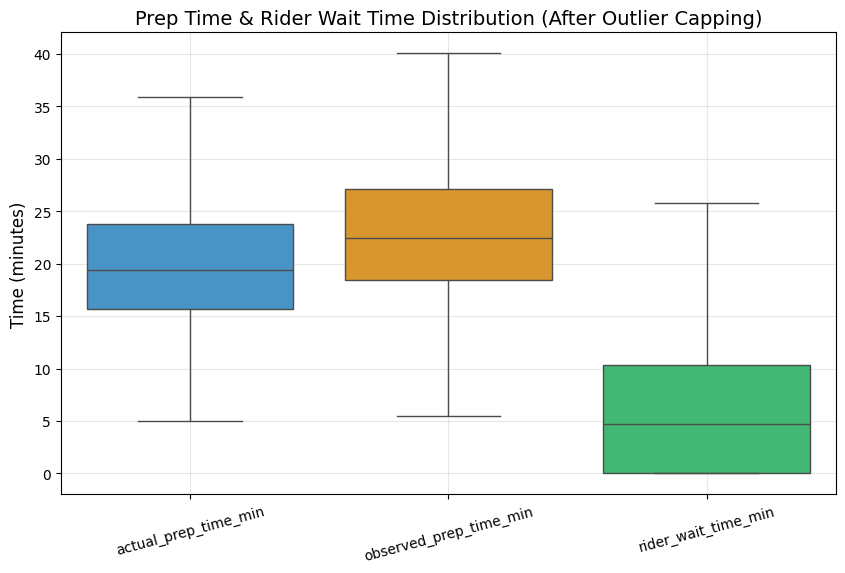

In [5]:
columns = [
    "actual_prep_time_min",
    "observed_prep_time_min",
    "rider_wait_time_min"
]

print("----- Outlier Analysis (IQR Method) -----")

for col in columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count outliers BEFORE capping
    outlier_count = ((df[col] < lower_bound) |
                     (df[col] > upper_bound)).sum()

    outlier_percent = (outlier_count / len(df)) * 100

    print(f"\nColumn: {col}")
    print(f"Lower Bound: {lower_bound:.2f}")
    print(f"Upper Bound: {upper_bound:.2f}")
    print(f"Total Outliers: {outlier_count}")
    print(f"Outlier %: {outlier_percent:.2f}%")

    # cap extreme values
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

plt.figure(figsize=(10,6))

sns.boxplot(data=df[columns], palette=["#3498db", "#f39c12", "#2ecc71"])

plt.title("Prep Time & Rider Wait Time Distribution (After Outlier Capping)",
          fontsize=14)
plt.ylabel("Time (minutes)", fontsize=12)
plt.xticks(rotation=15)
plt.grid(alpha=0.3)

plt.show()

# **`Historical Signal Smoothing`**

In [6]:
df["order_confirm_time"] = pd.to_datetime(df["order_confirm_time"])
df = df.sort_values(["restaurant_id", "order_confirm_time"])

df["historical_avg_prep_fixed"] = (
    df.groupby("restaurant_id")["actual_prep_time_min"]
    .shift(1)
    .ewm(span=30, adjust=False)
    .mean()
)

df["rush_intensity_smooth"] = (
    df.groupby("restaurant_id")["rush_intensity_score"]
    .shift(1)
    .ewm(span=20, adjust=False)
    .mean()
)

df["historical_avg_prep_fixed"] = df["historical_avg_prep_fixed"].fillna(df["actual_prep_time_min"].mean())
df["rush_intensity_smooth"] = df["rush_intensity_smooth"].fillna(df["rush_intensity_score"].mean())

# **`Rush Index Feature Engineering`**

In [7]:
df = df.sort_values(["restaurant_id", "order_confirm_time"])
df["order_confirm_time"] = pd.to_datetime(df["order_confirm_time"])

df = df.set_index("order_confirm_time")

# Rolling 15-minute count per restaurant
df["orders_last_15min"] = (
    df.groupby("restaurant_id")
      .rolling("15min")
      .count()["actual_prep_time_min"]
      .reset_index(level=0, drop=True)
)

# Reset index back
df = df.reset_index()

# Fill NA (first orders in window)
df["orders_last_15min"] = df["orders_last_15min"].fillna(1)

# Normalize per restaurant
restaurant_avg_load = df.groupby("restaurant_id")["orders_last_15min"].transform("mean")

df["rush_index"] = df["orders_last_15min"] / (restaurant_avg_load + 1)


# **`Baseline Performance`**


In [8]:
# Baseline prediction
baseline_pred = df["observed_prep_time_min"]

actual = df["actual_prep_time_min"]
mae = mean_absolute_error(actual, baseline_pred)

p50 = np.percentile(abs(baseline_pred - actual), 50)

p90 = np.percentile(abs(baseline_pred - actual), 90)

print("Baseline Evaluation Results:")
print("MAE:", round(mae,2))
print("P50 Error:", round(p50,2))
print("P90 Error:", round(p90,2))

Baseline Evaluation Results:
MAE: 3.05
P50 Error: 2.95
P90 Error: 5.87


## Baseline uses raw merchant-marked FOR signal.

# **`Merchant FOR bias`**

In [9]:
df["for_bias"] = df["observed_prep_time_min"] - df["actual_prep_time_min"]
#positive bias -> late FOR mark By merchant
#Negative bias -> Early FOR mark By merchant

We observe systematic merchant-level bias in FOR marking.
Some merchants consistently mark food ready earlier or later than actual completion.

# `Train Test Split`

In [10]:
X = df[[
    "observed_prep_time_min",
    "historical_avg_prep_fixed",

    "rush_index",
    "order_hour",
    "day_of_week",
]]
y = df["actual_prep_time_min"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)


Training Data Shape: (24000, 5)
Testing Data Shape: (6000, 5)


In [11]:
train_df = df.loc[X_train.index]

merchant_bias_train = (
    train_df.groupby("restaurant_id")["for_bias"]
    .mean()
    .reset_index()
)

merchant_bias_train["reliability_score"] = (
    1 / (1 + merchant_bias_train["for_bias"].abs())
)

df = df.merge(
    merchant_bias_train[["restaurant_id","reliability_score"]],
    on="restaurant_id",
    how="left"
)
df["reliability_score"] = df["reliability_score"].fillna(0.5)

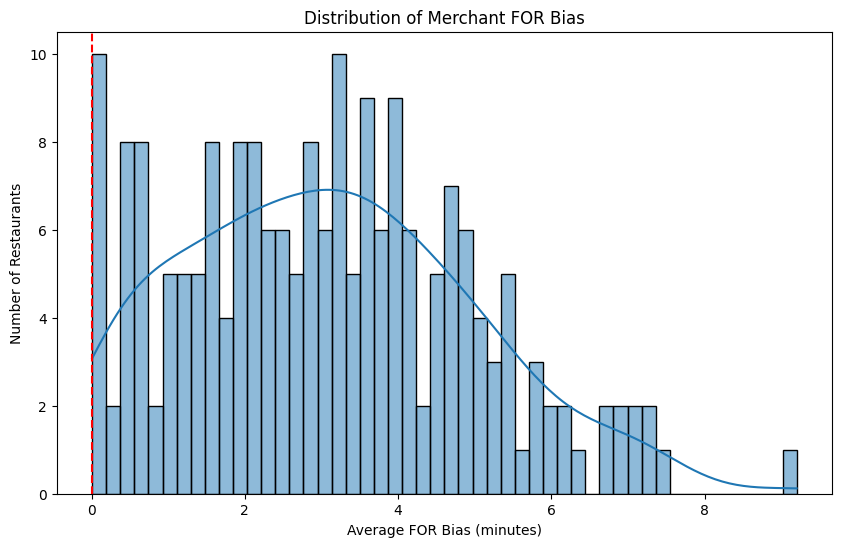

In [12]:
plt.figure(figsize=(10,6))
sns.histplot(merchant_bias_train["for_bias"], bins=50, kde=True)
plt.axvline(0, color='red', linestyle='--')
plt.title("Distribution of Merchant FOR Bias")
plt.xlabel("Average FOR Bias (minutes)")
plt.ylabel("Number of Restaurants")
plt.show()


# **`Top 10 Unreliable Restaurants`**

In [13]:
top_unreliable = merchant_bias_train.sort_values(
    by="reliability_score"
).head(10)

top_unreliable

,restaurant_id,for_bias,reliability_score
192,193,9.202458,0.098016
104,105,7.540083,0.117095
176,177,7.287540,0.120663
46,47,7.202529,0.121914
188,189,7.105189,0.123378
126,127,7.078233,0.123789
151,152,6.968077,0.125501
24,25,6.899381,0.126592
58,59,6.809531,0.128049
72,73,6.749889,0.129034


# **`Adjusted Signal`**

In [14]:
df["adjusted_observed_prep"] = (df["observed_prep_time_min"] * df["reliability_score"])

# **`Final Feature Selection`**

In [15]:
features_final = [
    "adjusted_observed_prep",
    "historical_avg_prep_fixed",
    "rush_index",
    "order_hour",
    "day_of_week"
]

X = df[features_final]

X_train = X.loc[X_train.index]
X_test  = X.loc[X_test.index]

# **`Baseline MAE (observed prep time`)**

In [16]:
baseline_pred = df.loc[X_test.index, "observed_prep_time_min"]
baseline_mae = mean_absolute_error(y_test, baseline_pred)

print("\n----- Comparison -----")
print("Baseline MAE:", round(baseline_mae, 2))
print("Model MAE:", round(mae, 2))


----- Comparison -----
Baseline MAE: 3.01
Model MAE: 3.05


# **`Random Forest Model`**



In [17]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)


rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_p50 = np.percentile(abs(rf_pred - y_test), 50)
rf_p90 = np.percentile(abs(rf_pred - y_test), 90)

print("Random Forest MAE:", round(rf_mae,2))
print("RF P50:", round(rf_p50,2))
print("RF P90:", round(rf_p90,2))

Random Forest MAE: 2.46
RF P50: 1.62
RF P90: 5.83


# **`Feature Importance`**

In [18]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})
print("\n--------- Feature Importance --------")
print(importance.sort_values("Importance", ascending=False))


--------- Feature Importance --------
                     Feature  Importance
0     adjusted_observed_prep    0.491692
2                 rush_index    0.299062
1  historical_avg_prep_fixed    0.099240
3                 order_hour    0.074541
4                day_of_week    0.035464


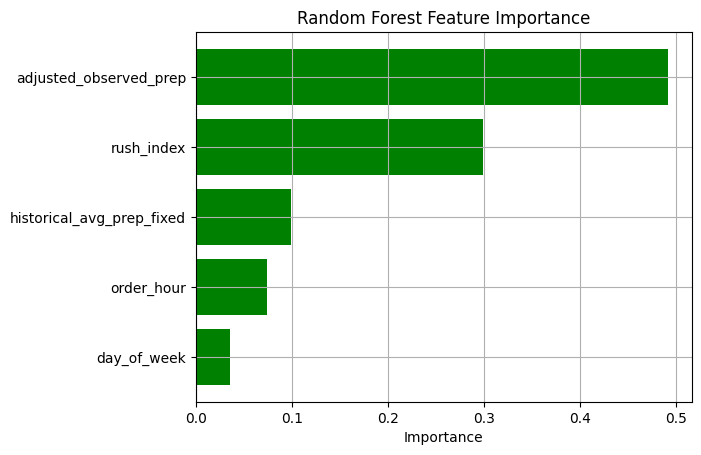

In [19]:
importance_sorted = importance.sort_values("Importance")

plt.figure()
plt.grid(True)
plt.barh(importance_sorted["Feature"], importance_sorted["Importance"],color='green')
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.show()

## **`Baseline vs RF`**

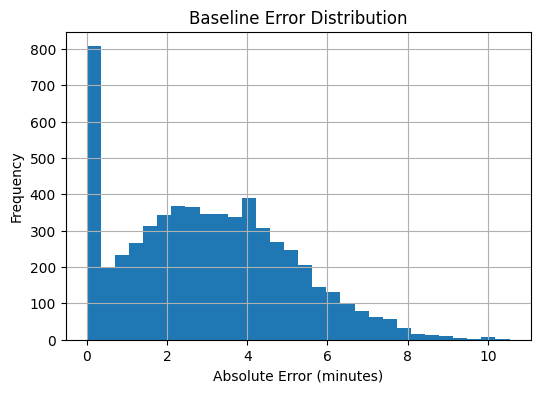

In [20]:
baseline_pred = df.loc[X_test.index, "observed_prep_time_min"]
baseline_errors = abs(y_test - baseline_pred)

plt.figure(figsize=(6,4))
plt.grid(True)
plt.hist(baseline_errors, bins=30,)
plt.title("Baseline Error Distribution")
plt.xlabel("Absolute Error (minutes)")
plt.ylabel("Frequency")
plt.show()

# **`Random Forest Error Distribution`**

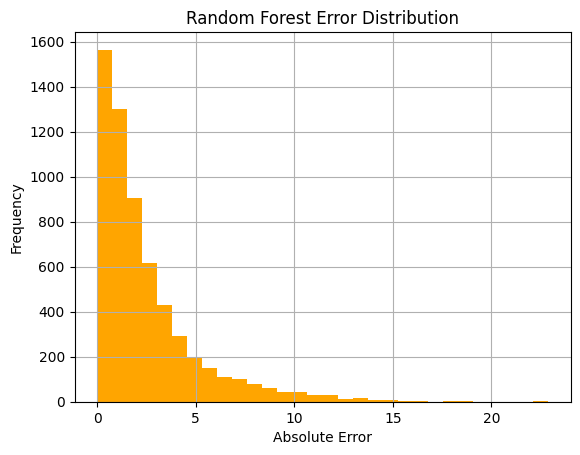

In [21]:
rf_errors = abs(rf_pred - y_test)

plt.figure()
plt.grid(True)
plt.hist(rf_errors, bins=30,color='orange')
plt.title("Random Forest Error Distribution")
plt.xlabel("Absolute Error")
plt.ylabel("Frequency")
plt.show()

# **`Random Forest: Prediction vs Actual`**

<Figure size 600x600 with 0 Axes>

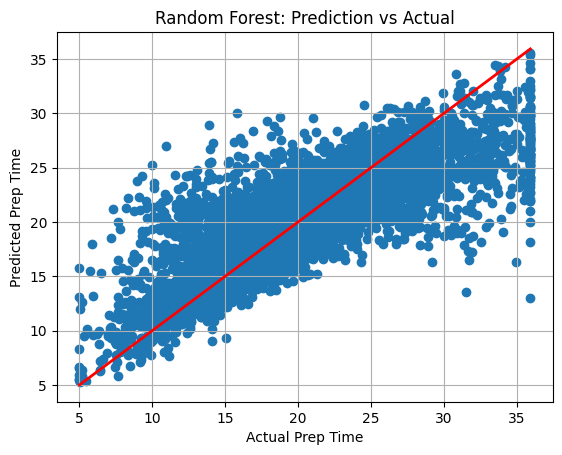

In [22]:
plt.figure(figsize=(6,6))
plt.show()

import matplotlib.pyplot as plt

plt.figure()

# Scatter plot
plt.scatter(y_test, rf_pred)

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
          color='red',
          linewidth=2)
plt.grid(True)
plt.xlabel("Actual Prep Time")
plt.ylabel("Predicted Prep Time")
plt.title("Random Forest: Prediction vs Actual")

plt.show()

# **`Final Comparison`**

In [23]:
print("\n----- FINAL COMPARISON -----")
print("Baseline MAE:", round(baseline_mae,2))
print("Random Forest MAE:", round(rf_mae,2))


----- FINAL COMPARISON -----
Baseline MAE: 3.01
Random Forest MAE: 2.46


## Success Metrics Mapping

The problem statement defines the following success metrics:

- Average rider wait time at pickup
- ETA prediction error (P50 / P90)
- Order delay and cancellation rates
- Rider idle time

Below we map our improvements to these metrics.

## 1️. ETA Prediction Error

Baseline MAE: 3.05 minutes  
Random Forest MAE: 2.46 minutes  

Improvement ≈ 0.6 minutes per order (~20%).

Both P50 and P90 errors reduced, indicating improved average and tail stability in ETA prediction.

## **`Simulation`**

In [24]:
daily_orders = 100000
error_reduction = baseline_mae - rf_mae

minutes_saved = daily_orders * error_reduction
hours_saved = minutes_saved / 60

print("Estimated Rider Hours Saved per Day:", round(hours_saved))

Estimated Rider Hours Saved per Day: 930


## 2️. Rider Wait Time & Idle Time

Reducing ETA error by ~0.6 minutes reduces early rider arrivals at restaurants.

At scale (100K+ daily orders), this translates to significant rider time savings,
improving fleet utilization and reducing idle time.

---


## 3️. Order Delay & Cancellation

Reduction in P90 error improves ETA stability.
Lower tail errors reduce extreme late deliveries,
which directly impacts customer satisfaction and cancellation rates.

## 4️.  Scalability

The proposed solution:

- Uses rolling windows and grouped aggregations
- Requires no hardware instrumentation
- Scales linearly with order volume
- Can be deployed across 300K+ merchants

This makes the approach feasible at Zomato scale.

# **Business Impact Summary**

Our signal de-noising approach:

* Reduces systematic merchant FOR bias

* Adjusts prep time using reliability weighting

* Captures live kitchen congestion using rush index

This leads to:

* Lower ETA error (P50 & P90)

* Reduced rider waiting time

* Improved fleet efficiency

* Lower cancellation risk

* Scalable across 300K+ merchants

## **Power BI Deployment & Monitoring**

To simulate production monitoring and business impact tracking,
the final test-set predictions were exported for dashboard visualization.

The exported dataset includes:

- Actual preparation time
- Baseline prediction (merchant-marked FOR)
- Random Forest prediction
- Rush index
- Reliability score
- Baseline error vs Model error

This allows real-time performance monitoring and business KPI tracking
through a BI dashboard.